In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

# Listening to Real Data

Loading and listening to real datasets here!

In [2]:
from nanodrz.data import DiarizationDataset, libritts_dev
from nanodrz.utils import visualise_annotation, play

In [3]:
ds = iter(DiarizationDataset("/home/harry/.cache/nanodrz/voxconverse-dev"))

In [4]:
from nanodrz.model import DiarizeGPT, Config
from nanodrz import data
from denoiser import pretrained
from denoiser.demucs import Demucs

from nanodrz.utils import play, resample, visualise_annotation
import torch



device = torch.device("cuda:1")
ckpt = torch.load("/home/harry/runs/nanodrz/1708873217/0008000.pt", map_location=device)
config = Config(**ckpt["config"])
model:DiarizeGPT = DiarizeGPT.from_pretrained(ckpt).cuda()

denoiser =  torch.compile(pretrained.dns64().cpu().eval())

@torch.inference_mode()
def denoise(denoiser, audio, sr=None):
    audio = audio.sum(dim=0, keepdim=True)
    return denoiser.cuda()(audio.cuda()).cpu()


/home/harry/nanodrz/.venv/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:28: UserWarning: torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.
  warnings.warn("torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.")


[ 00:00:00.000 -->  00:00:03.417] _ D
[ 00:00:03.497 -->  00:00:04.337] _ D
[ 00:00:04.417 -->  00:00:11.577] _ D
[ 00:00:10.217 -->  00:00:18.777] _ A
[ 00:00:19.577 -->  00:00:21.509] _ A


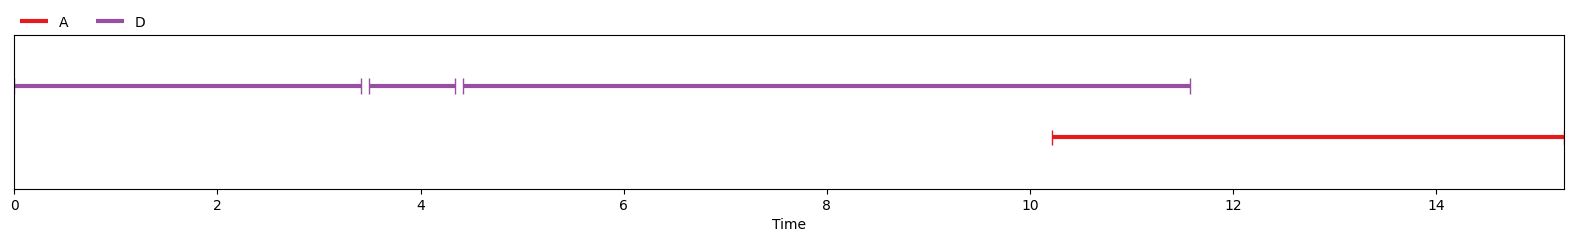

In [19]:
audio, labels = next(ds)
audio = audio.sum(dim=0)[None]
audio = audio / audio.abs().max()
sr = 16000
audio = audio[:, : sr * 15]
audio = denoise(denoiser, audio)
play(audio)
visualise_annotation(labels)

[ 00:00:00.956 -->  00:00:02.151] _ A
[ 00:00:02.390 -->  00:00:02.988] _ A
[ 00:00:03.466 -->  00:00:04.063] _ A
[ 00:00:04.422 -->  00:00:04.780] _ A
[ 00:00:04.900 -->  00:00:05.258] _ A
[ 00:00:05.617 -->  00:00:09.800] _ A
[ 00:00:09.920 -->  00:00:10.278] _ A
[ 00:00:10.278 -->  00:00:11.354] _ A
[ 00:00:10.876 -->  00:00:14.940] _ B
[ 00:00:14.581 -->  00:00:15.059] _ A


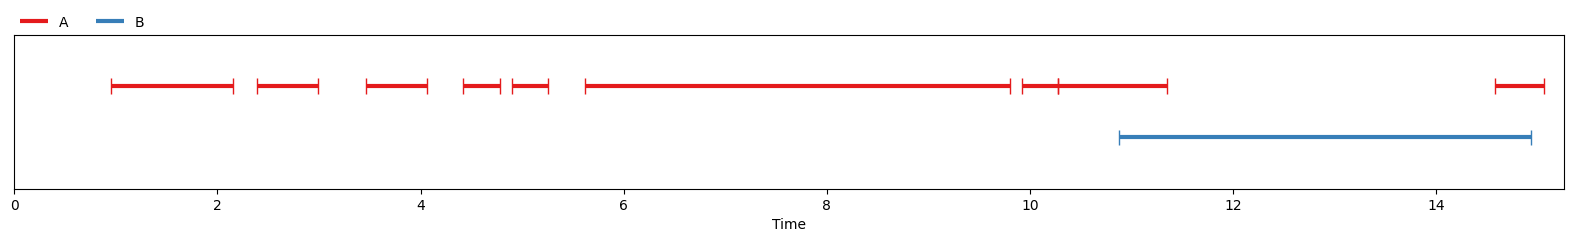

In [24]:
nlabels = model.generate(audio[:,:15*sr].cuda(), temperature=.2, max_steps=10*3)
visualise_annotation(nlabels)
play(audio)